In [1]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import rdmodel as model
import rdmodel_jit as fast
#import calibrate as calibrate
#import estimate as estimate
import output_latex as output_latex


import numpy as np
import matplotlib.pyplot as plt 
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pandas as pd
import scipy.optimize as opt
from scipy.optimize import fsolve
import estimagic as em



#from Solve_NFXP import solve_NFXP
#import estimate_NFXP as estimate

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/__init__.py:79: FutureWarning: estimagic has been renamed to optimagic, but you have estimagic installed. Please uninstall estimagic and install optimagic instead. Don't worry, your estimagic imports will still work if you install optimagic, and simple warnings will help you to adjust them for future releases.

To make these changes using pip, run:
-------------------------------------
$ pip uninstall estimagic
$ pip install optimagic

For conda users, use:
---------------------
$ conda remove estimagic
$ conda install -c conda-forge optimagic

For more details see the documentation: https://optimagic.readthedocs.io/en/latest/installation.html
  warnings.warn(installation_warning_message, FutureWarning)


In [2]:
eta = 0
lam = 0
N = 0
delta = .93
gamma = .35
k1 = 173.1
k2 = 49.6
k3 = 12.9
q1= 0.21
q2 = 0.63
params_multi = np.array([eta, lam, N, delta, gamma, k1, k2, k3, q1, q2])

### Define Institutions, and simulate moments given our parameters and instutions

In [3]:
# Get institutions for Hungary
institutions_pre_H, institutions_post_H = model.getInstitutions('Hungary')

# Simulate moments for Hungary
moments_H = model.simulate_moments(params_multi, institutions_pre_H, institutions_post_H)
# Create time vector for Hungary
timevec_H = np.arange((len(moments_H))/2)*15 + 15


# Get institutions for Germany
institutions_pre_G, institutions_post_G = model.getInstitutions('Germany')

# Simulate moments for Germany
moments_G = model.simulate_moments(params_multi, institutions_pre_G, institutions_post_G)
# Create time vector for Germany
timevec_G = np.arange((len(moments_G))/2) + 1

In [4]:
len(timevec_H)

35

### Collect empirical moments and the empirical covariance matrix 

In [5]:
# Get empirical moments and covariance matrices for Hungary and Germany
target_H, cov_H = model.matchingMoments('Hungary')
target_G, cov_G = model.matchingMoments('Germany')

In [6]:
len(institutions_pre_H[3])
len(institutions_post_H[3])

44

In [7]:
moments_H.shape

(70,)

#### The weighting matrix
Inverse of the empircal covariance matrix

In [8]:
# create weighting matrices for Hungary and Germany
W_H = np.linalg.inv(cov_H)
W_G = np.linalg.inv(cov_G)


#### SSE

In [9]:
# Create the SSE for Hungary and Germany
SSE_H = model.sse(params_multi, target_H, W_H, institutions_pre_H, institutions_post_H)
SSE_G = model.sse(params_multi, target_G, W_G, institutions_pre_G, institutions_post_G)

In [10]:
print(f'SSE (Goodness of Fit) for Hungary: {SSE_H}')
print(f'SSE (Goodness of Fit) for Germany: {SSE_G}')

SSE (Goodness of Fit) for Hungary: 257.6465317211423
SSE (Goodness of Fit) for Germany: 12089.588630191509


## Create DellaVigna figure

In [11]:
def split_half(arr):
    mid = len(arr) // 2
    return arr[:mid], arr[mid:]

H_pre, H_post = split_half(moments_H)
G_pre, G_post = split_half(moments_G)

emp_H_pre, emp_H_post = split_half(target_H)
emp_G_pre, emp_G_post = split_half(target_G)


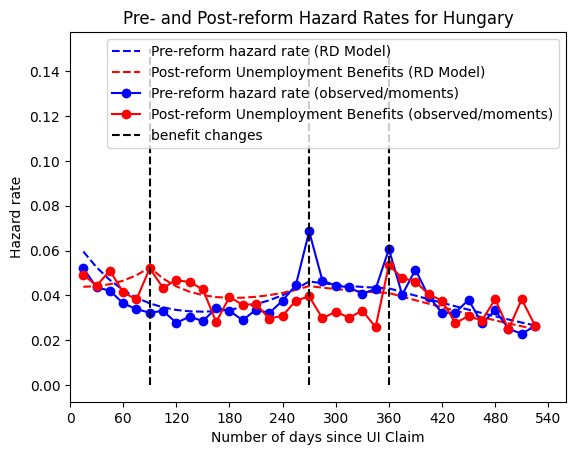

In [12]:
plt.plot(timevec_H, H_pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec_H, H_post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec_H, emp_H_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec_H, emp_H_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of days since UI Claim')
plt.xlim(0, 560) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre- and Post-reform Hazard Rates for Hungary')
plt.vlines(x=[6*15, 18*15, 24*15], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

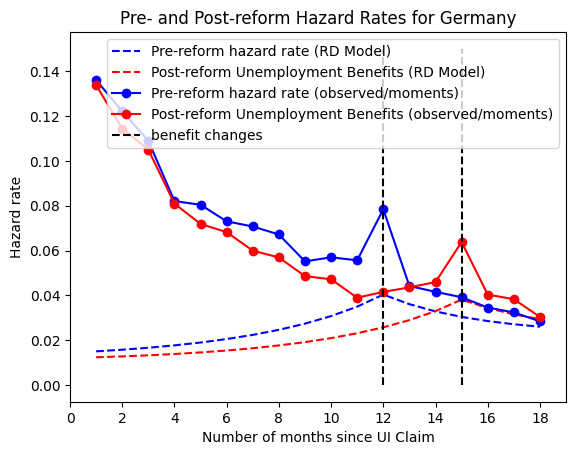

In [13]:

plt.plot(timevec_G, G_pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec_G, G_post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec_G, emp_G_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec_G, emp_G_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of months since UI Claim')
plt.xlim(0, 19) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre- and Post-reform Hazard Rates for Germany')
plt.vlines(x=[12, 15, ], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

# Calibrate the model

### Calibrating $\gamma$
let's have $\gamma \in [0.1, 2]$ with 50 steps and plotting $SSE(\gamma)$ in this interval


In [14]:
n_steps = 50
gamma_start = 0.1
gamma_stop = 2
stepsize = (gamma_stop - gamma_start) / (n_steps)
gamma = np.arange(gamma_start, gamma_stop, stepsize)


In [15]:
# simulate moments for Germany with varying gamma values
SSE_G = []
for g in gamma:
    params_multi[4] = g  # update gamma in params_multi
    SSE_G.append(model.sse(params_multi, target_G, W_G, institutions_pre_G, institutions_post_G))
    

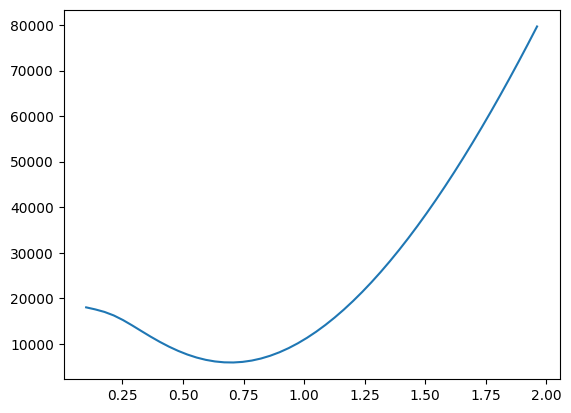

In [16]:
# plot SSE with the varying gamma values for Germany
plt.plot(gamma, SSE_G, label='Germany')

SSE seems to be minimized around 0.75, so probably the gamma value in our range of 0.706 or 0.746

In [17]:
def sse_g(val):
    return model.sse([eta, lam, N, delta, float(val),k1, k2, k3, q1, q2], target_G, W_G, institutions_pre_G, institutions_post_G)
x0 = 0.5
results = opt.minimize(sse_g, x0, method='L-BFGS-B', bounds=((0.1, 2),), options={'disp': True})
print(f'Optimal gamma for Germany: {results.x[0]}')

Optimal gamma for Germany: 0.6965166251676583


/var/folders/px/brv0p26n7szcpwsq7dm55yy00000gn/T/ipykernel_39906/3633533552.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return model.sse([eta, lam, N, delta, float(val),k1, k2, k3, q1, q2], target_G, W_G, institutions_pre_G, institutions_post_G)


In [18]:
eta = 0
lam = 0
N = 0
delta = .93
gamma = results.x[0]  # use the optimal gamma found from the previous optimization
k1 = 173.1
k2 = 49.6
k3 = 12.9
q1= 0.21
q2 = 0.63
params_multi = np.array([eta, lam, N, delta, gamma, k1, k2, k3, q1, q2])
moments_G = model.simulate_moments(params_multi, institutions_pre_G, institutions_post_G)
SSE_G = model.sse(params_multi, target_G, W_G, institutions_pre_G, institutions_post_G)
G_pre, G_post = split_half(moments_G)
print(f'Goodness of fit for Germany: {SSE_G}')
print(f'Gamma: {gamma}')


Goodness of fit for Germany: 5890.504699404662
Gamma: 0.6965166251676583


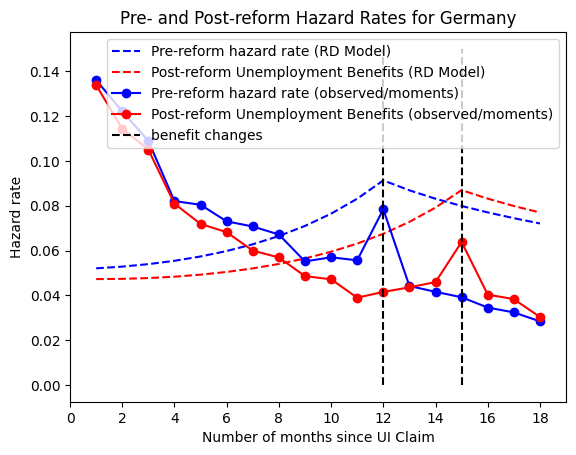

In [19]:
plt.plot(timevec_G, G_pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec_G, G_post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec_G, emp_G_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec_G, emp_G_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of months since UI Claim')
plt.xlim(0, 19) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre- and Post-reform Hazard Rates for Germany')
plt.vlines(x=[12, 15, ], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

## Calibrating $\gamma$ and $\delta$

In [20]:
def sse_gd(val):
    #gamma = float(val[0])
    #delta = float(val[1])
    return model.sse([eta, lam, N, float(val[1]), float(val[0]), k1, k2, k3, q1, q2], target_G, W_G, institutions_pre_G, institutions_post_G)
x0 = np.array([0.5, 0.5])  # initial guess for [gamma, delta]
results = opt.minimize(sse_gd, x0, method='L-BFGS-B', bounds=((0.1, 2),(0,1)), options={'disp': True})
print(f'Optimal gamma for Germany: {results.x[0]}, Optimal delta for Germany: {results.x[1]}')

Optimal gamma for Germany: 0.19166175441993544, Optimal delta for Germany: 0.9851802508124612


/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Python/PS1_python_Templates/PS2_templates/rdmodel.py:253: RuntimeWarning: divide by zero encountered in scalar divide
  V_E[t] = v(w_post) / (1-delta)
/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Python/PS1_python_Templates/PS2_templates/rdmodel.py:80: RuntimeWarning: invalid value encountered in scalar subtract
  search = min(1,max(delta/k*(Ve-Vu),0))**(1/gamma)
/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Python/PS1_python_Templates/PS2_templates/rdmodel.py:99: RuntimeWarning: invalid value encountered in scalar multiply
  gap = v(benefits[-1])-cost(s,k,gamma)+delta* (s * Ve + (1-s) * Vu) - Vu
/Users/jacobaspnissen/Desktop/Økonomi/Dynamic programming/Python/PS1_python_Templates/PS2_templates/rdmodel.py:276: RuntimeWarning: invalid value encountered in scalar multiply
  - cost(s[t],k,gamma)+delta* (s[t]* V_E[t+1] + (1-s[t])*V_U[t+1])


In [21]:
eta = 0
lam = 0
N = 0
delta = results.x[1]  # use the optimal delta found from the previous optimization
gamma = results.x[0]  # use the optimal gamma found from the previous optimization
k1 = 173.1
k2 = 49.6
k3 = 12.9
q1= 0.21
q2 = 0.63
params_multi = np.array([eta, lam, N, delta, gamma, k1, k2, k3, q1, q2])
moments_G = model.simulate_moments(params_multi, institutions_pre_G, institutions_post_G)
SSE_G = model.sse(params_multi, target_G, W_G, institutions_pre_G, institutions_post_G)
G_pre, G_post = split_half(moments_G)
print(f'Goodness of fit for Germany: {SSE_G}')
print(f'Gamma: {gamma}, Delta: {delta}')

Goodness of fit for Germany: 4837.170180981022
Gamma: 0.19166175441993544, Delta: 0.9851802508124612


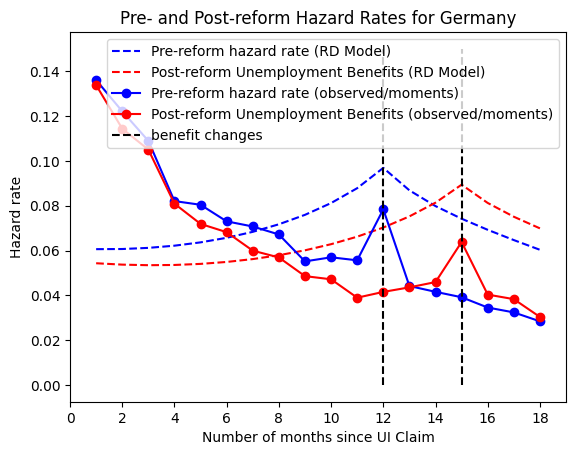

In [22]:
plt.plot(timevec_G, G_pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec_G, G_post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec_G, emp_G_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec_G, emp_G_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of months since UI Claim')
plt.xlim(0, 19) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre- and Post-reform Hazard Rates for Germany')
plt.vlines(x=[12, 15, ], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

# Speeding up the calibrating process

Now using the Numba library to take function code (python code) and compile it into machine code. Since compiled code runs much faster than interpreted code. This is fact will make our model run a similar speeds as if we had programmed it in C.

In [23]:
eta = 0
lam = 0
N = 0
delta = .93
gamma = 0.35 
k1 = 173.1
k2 = 49.6
k3 = 12.9
q1= 0.21
q2 = 0.63
Fixed_params = np.array([eta, lam, N, delta, gamma, k1, k2, k3, q1, q2])

In [24]:
sse1 = model.sse(Fixed_params, target_G, W_G, institutions_pre_G, institutions_post_G)
sse2 = fast.sse(Fixed_params, target_G, W_G, institutions_pre_G, institutions_post_G)
np.isclose(sse1, sse2)

np.True_

In [25]:
%timeit model.sse(Fixed_params, target_G, W_G, institutions_pre_G, institutions_post_G)

2.52 ms ± 20.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [26]:
%timeit fast.sse(Fixed_params, target_G, W_G, institutions_pre_G, institutions_post_G)

214 μs ± 64.7 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


When using the numba njit function the sse calculation times are decreases by quite a lot.
While the standard model takes around 3.61 ms (milliseconds) per loop, the njit model runs at 233 $\mu s$ (microseconds, 1/1000 of a millisecond) per loop

# Estimating all parameters

## GMM

In [27]:
params_full = pd.DataFrame(
    data={"value":[0,0,0,.93,0.35,173.1,49.6,12.9,.21,.63]},
    index=["eta", "lam", "N", "delta", "gamma", "k1", "k2", "k3", "q1", "q2"]
    )


Create instance of GMM class defined in in rdmodel_jit

In [28]:
gmm_object = fast.gmm(params_full.copy(), target_G, W_G, institutions_pre_G, institutions_post_G)

In [29]:
params = pd.DataFrame(
    data={"value":[0.3],
    "lower_bound" : [0.01],
    "upper_bound" : [2]},
    index=["gamma"],
    )

In [30]:
print(f'GMM SSE for gamma=0.3: {gmm_object.sse(params)}')

GMM SSE for gamma=0.3: 13719.28464730645


## Optimizing gamma using GMM
We use the estimagic library

### Estimating gamma

In [31]:
res = em.minimize(criterion=gmm_object.sse, params=params, algorithm='scipy_lbfgsb', )

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/decorators.py:125: FutureWarning: estimagic.minimize has been deprecated in version 0.5.0. Use optimagic.minimize instead. This function will be removed in version 0.6.0.
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


In [32]:
print(f'Optimized gamma parameter: {res.params}')
print(f'Objective function(SSE) at optimized gamma (minimum): {res.criterion}')

Optimized gamma parameter:           value  lower_bound  upper_bound
gamma  0.696516         0.01            2
Objective function(SSE) at optimized gamma (minimum): 5890.504699433577


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning: The criterion attribute is deprecated. Use the fun attribute instead.
  warnings.warn(msg, FutureWarning)


In [33]:
gmm_object.params_full.update(res.params)
print(gmm_object.params_full)

            value
eta      0.000000
lam      0.000000
N        0.000000
delta    0.930000
gamma    0.696516
k1     173.100000
k2      49.600000
k3      12.900000
q1       0.210000
q2       0.630000


### Estimating 7 parameters

In [34]:
params = pd.DataFrame(
    data={"value":[0.98, 0.1, 100, 20, 10, 0.3, 0.3],
    "lower_bound" : [0.01, 1e-2, 1e-5, 1e-5, 1e-5, 0, 0],
    "upper_bound" : [0.999, 2, 2000, 2000, 2000, 1, 1]},
    index=["delta","gamma", "k1", "k2", "k3", "q1", "q2"],
    )

In [35]:
res = em.minimize(criterion=gmm_object.sse, params=params, algorithm='scipy_lbfgsb', )

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/decorators.py:125: FutureWarning: estimagic.minimize has been deprecated in version 0.5.0. Use optimagic.minimize instead. This function will be removed in version 0.6.0.
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


In [36]:
print(f'Optimized parameters: {res.params}')
print(f'Objective function(SSE) at minimum: {res.criterion}')

Optimized parameters:             value  lower_bound  upper_bound
delta    0.985290      0.01000        0.999
gamma    0.081780      0.01000        2.000
k1     101.292148      0.00001     2000.000
k2      34.357543      0.00001     2000.000
k3      11.460317      0.00001     2000.000
q1       0.400801      0.00000        1.000
q2       0.109996      0.00000        1.000
Objective function(SSE) at minimum: 58.43425040374878


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning: The criterion attribute is deprecated. Use the fun attribute instead.
  warnings.warn(msg, FutureWarning)


In-sample fit plot

In [37]:
# take first column of res.params dataframe
parameters = res.params["value"].to_numpy().flatten()  # convert to numpy array and flatten to 1D
delta, gamma, k1, k2, k3, q1, q2 = parameters

In [38]:

params_multi = np.array([eta, lam, N, delta, gamma, k1, k2, k3, q1, q2])
moments_G = fast.simulate_moments(params_multi, institutions_pre_G, institutions_post_G)
SSE_G = fast.sse(params_multi, target_G, W_G, institutions_pre_G, institutions_post_G)
G_pre, G_post = split_half(moments_G)
print(f'Goodness of fit for Germany: {SSE_G}')

Goodness of fit for Germany: 58.43425040374878


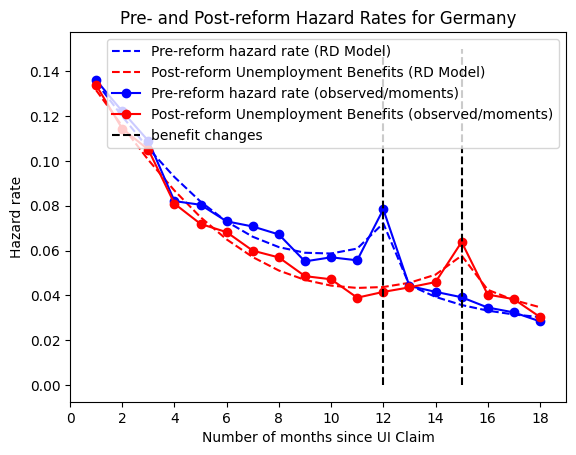

In [39]:
plt.plot(timevec_G, G_pre, label='Pre-reform hazard rate (RD Model)', linestyle='dashed', color='blue')
plt.plot(timevec_G, G_post, label='Post-reform Unemployment Benefits (RD Model)', linestyle='dashed', color='red')
plt.plot(timevec_G, emp_G_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec_G, emp_G_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of months since UI Claim')
plt.xlim(0, 19) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre- and Post-reform Hazard Rates for Germany')
plt.vlines(x=[12, 15, ], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

#### Estimate using alternative starting values

In [40]:
res.params

,value,lower_bound,upper_bound
delta,0.985290,0.01000,0.999
gamma,0.081780,0.01000,2.000
k1,101.292148,0.00001,2000.000
k2,34.357543,0.00001,2000.000
k3,11.460317,0.00001,2000.000
q1,0.400801,0.00000,1.000
q2,0.109996,0.00000,1.000


In [41]:
params

,value,lower_bound,upper_bound
delta,0.98,0.01000,0.999
gamma,0.10,0.01000,2.000
k1,100.00,0.00001,2000.000
k2,20.00,0.00001,2000.000
k3,10.00,0.00001,2000.000
q1,0.30,0.00000,1.000
q2,0.30,0.00000,1.000


In [42]:
params_init1 = np.array([0.6, 0.1, 100, 20, 10, 0.3, 0.3])
params1 = params.copy()
params1["value"] = params_init1
print(params1)
res1 = em.minimize(criterion=gmm_object.sse, params=params1, algorithm='scipy_lbfgsb', )
print(res1.params)
print(f'S1:Objective function(SSE) at minimum: {res1.criterion}')

       value  lower_bound  upper_bound
delta    0.6      0.01000        0.999
gamma    0.1      0.01000        2.000
k1     100.0      0.00001     2000.000
k2      20.0      0.00001     2000.000
k3      10.0      0.00001     2000.000
q1       0.3      0.00000        1.000
q2       0.3      0.00000        1.000


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/decorators.py:125: FutureWarning: estimagic.minimize has been deprecated in version 0.5.0. Use optimagic.minimize instead. This function will be removed in version 0.6.0.
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


           value  lower_bound  upper_bound
delta   0.787626      0.01000        0.999
gamma   0.880357      0.01000        2.000
k1     99.680105      0.00001     2000.000
k2      4.608673      0.00001     2000.000
k3      1.744540      0.00001     2000.000
q1      0.413051      0.00000        1.000
q2      0.452427      0.00000        1.000
S1:Objective function(SSE) at minimum: 64.91573159483372


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning: The criterion attribute is deprecated. Use the fun attribute instead.
  warnings.warn(msg, FutureWarning)


In [43]:
params_init2 = np.array([0.8, 0.8, 100, 60, 10, 0.2, 0.2])
params2 = params.copy()
params2["value"] = params_init2
print(params2)
res2 = em.minimize(criterion=gmm_object.sse, params=params2, algorithm='scipy_lbfgsb', )
print(f'S2: {res2.params}')
print(f'S2:Objective function(SSE) at minimum: {res2.criterion}')

       value  lower_bound  upper_bound
delta    0.8      0.01000        0.999
gamma    0.8      0.01000        2.000
k1     100.0      0.00001     2000.000
k2      60.0      0.00001     2000.000
k3      10.0      0.00001     2000.000
q1       0.2      0.00000        1.000
q2       0.2      0.00000        1.000


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/decorators.py:125: FutureWarning: estimagic.minimize has been deprecated in version 0.5.0. Use optimagic.minimize instead. This function will be removed in version 0.6.0.
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


S2:            value  lower_bound  upper_bound
delta   0.946501      0.01000        0.999
gamma   0.282729      0.01000        2.000
k1     86.412856      0.00001     2000.000
k2     24.977918      0.00001     2000.000
k3      4.647893      0.00001     2000.000
q1      0.275667      0.00000        1.000
q2      0.220517      0.00000        1.000
S2:Objective function(SSE) at minimum: 58.72871019750191


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning: The criterion attribute is deprecated. Use the fun attribute instead.
  warnings.warn(msg, FutureWarning)


In [44]:
params_init3 = np.array([0.5, 0.8, 10, 10, 10, 0.1, 0.1])
params3 = params.copy()
params3["value"] = params_init3
print(params3)
res3 = em.minimize(criterion=gmm_object.sse, params=params3, algorithm='scipy_lbfgsb', )
print(f'S3: {res3.params}')
print(f'S3:Objective function(SSE) at minimum: {res3.criterion}')

       value  lower_bound  upper_bound
delta    0.5      0.01000        0.999
gamma    0.8      0.01000        2.000
k1      10.0      0.00001     2000.000
k2      10.0      0.00001     2000.000
k3      10.0      0.00001     2000.000
q1       0.1      0.00000        1.000
q2       0.1      0.00000        1.000


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/decorators.py:125: FutureWarning: estimagic.minimize has been deprecated in version 0.5.0. Use optimagic.minimize instead. This function will be removed in version 0.6.0.
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


S3:              value  lower_bound  upper_bound
delta     0.997898      0.01000        0.999
gamma     1.999993      0.01000        2.000
k1     2000.000000      0.00001     2000.000
k2     2000.000000      0.00001     2000.000
k3     2000.000000      0.00001     2000.000
q1        0.000006      0.00000        1.000
q2        0.000006      0.00000        1.000
S3:Objective function(SSE) at minimum: 4218.378001272925


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning: The criterion attribute is deprecated. Use the fun attribute instead.
  warnings.warn(msg, FutureWarning)


In [45]:
params

,value,lower_bound,upper_bound
delta,0.98,0.01000,0.999
gamma,0.10,0.01000,2.000
k1,100.00,0.00001,2000.000
k2,20.00,0.00001,2000.000
k3,10.00,0.00001,2000.000
q1,0.30,0.00000,1.000
q2,0.30,0.00000,1.000


In-sample fit for alternative starting values:

In [46]:
# take first column of res.params dataframe
parameters1 = res1.params["value"].to_numpy().flatten()  # convert to numpy array and flatten to 1D
#delta, gamma, k1, k2, k3, q1, q2 = parameters1

parameters2 = res2.params["value"].to_numpy().flatten()  # convert to numpy array and flatten to 1D
delta, gamma, k1, k2, k3, q1, q2 = parameters2

parameters3 = res3.params["value"].to_numpy().flatten()  # convert to numpy array and flatten to 1D
#delta, gamma, k1, k2, k3, q1, q2 = parameters3

In [47]:
params_multi = np.array([eta, lam, N, delta, gamma, k1, k2, k3, q1, q2])
moments_G = fast.simulate_moments(params_multi, institutions_pre_G, institutions_post_G)
SSE_G = fast.sse(params_multi, target_G, W_G, institutions_pre_G, institutions_post_G)
G_pre, G_post = split_half(moments_G)
print(f'Goodness of fit for Germany: {SSE_G}')

Goodness of fit for Germany: 58.72871019750191


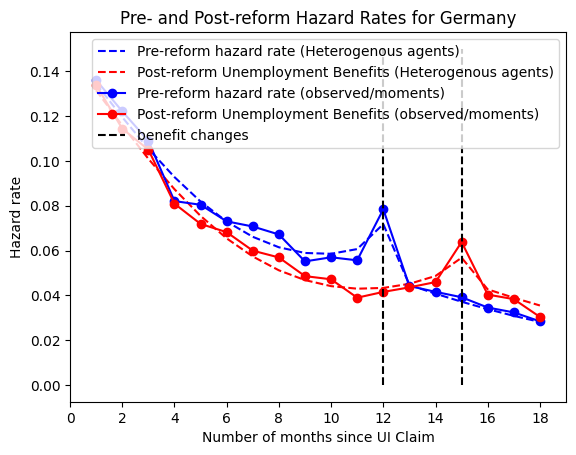

In [48]:
plt.plot(timevec_G, G_pre, label='Pre-reform hazard rate (Heterogenous agents)', linestyle='dashed', color='blue')
plt.plot(timevec_G, G_post, label='Post-reform Unemployment Benefits (Heterogenous agents)', linestyle='dashed', color='red')
plt.plot(timevec_G, emp_G_pre, label='Pre-reform hazard rate (observed/moments)', marker='o', color='blue')
plt.plot(timevec_G, emp_G_post, label='Post-reform Unemployment Benefits (observed/moments)', marker='o', color='red')

plt.xlabel('Number of months since UI Claim')
plt.xlim(0, 19) # set x-axis limits to first and last element in timevec
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(11))  # at most 8 ticks
plt.ylabel('Hazard rate')
plt.title('Pre- and Post-reform Hazard Rates for Germany')
plt.vlines(x=[12, 15, ], ymin=0, ymax=0.15, colors='black', linestyles='dashed', label='benefit changes')
plt.legend()
plt.show()

## Estimagic - Sliceplot

In [49]:
fig = em.slice_plot(
    func=gmm_object.sse,
    params=res3.params['value'],
    lower_bounds=res3.params['lower_bound'],
    upper_bounds=res3.params['upper_bound'],
    # selecting a subset of params
    #selector=lambda x: [x["alpha"], x["beta"]],
    # evaluate func in parallel
    n_cores=4,
)
fig.update_yaxes(range=[0, 30000])   # choose a smaller upper bound
fig.show() #(renderer="png")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/decorators.py:125: FutureWarning: estimagic.slice_plot has been deprecated in version 0.5.0. Use optimagic.slice_plot instead. This function will be removed in version 0.6.0.
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:247: FutureWarning: Specifying bounds via the arguments lower_bound, and upper_bound is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the `bounds` argument instead.
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/__init__.py:79: FutureWarning: estimagic has been renamed to optimagic, but you have estimagic installed. Please uninstall estimagic and install optimagic instead. Don't worry, your estimagic imports will still work if you install optimagic, and simple warnings will h

In [50]:
fig = em.slice_plot(
    func=gmm_object.sse,
    params=res.params['value'],
    lower_bounds=res.params['lower_bound'],
    upper_bounds=res.params['upper_bound'],
    # selecting a subset of params
    #selector=lambda x: [x["alpha"], x["beta"]],
    # evaluate func in parallel
    n_cores=4,
)
fig.update_yaxes(range=[0, 30000])   # choose a smaller upper bound
fig.show() #(renderer="png")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/decorators.py:125: FutureWarning:

estimagic.slice_plot has been deprecated in version 0.5.0. Use optimagic.slice_plot instead. This function will be removed in version 0.6.0.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:247: FutureWarning:

Specifying bounds via the arguments lower_bound, and upper_bound is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the `bounds` argument instead.



# Finding Global Minimum with Multistart
Most optimization algorithms search for local minima, thus they are sensitive to starting values. 

One approach is to use multiple starting values and then choose the solutions with the lowest SSE as the estimate.

Another approach could be to use global optimization routines

No matter the approach it's a tricky issue and some experimentation is alwaus needed.

Estimagic has the solution to this, as both approached are included in the libary. As goes for the first approach, it is possible to use the option: Multistart

In [51]:
res4 = em.minimize(criterion=gmm_object.sse, params=params, algorithm='scipy_lbfgsb', multistart=True,) 

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/decorators.py:125: FutureWarning:

estimagic.minimize has been deprecated in version 0.5.0. Use optimagic.minimize instead. This function will be removed in version 0.6.0.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/deprecations.py:31: FutureWarning:

To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.



In [52]:
print(res.params)
print(f'Objective function(SSE) at minimum: {res.criterion}')

            value  lower_bound  upper_bound
delta    0.985290      0.01000        0.999
gamma    0.081780      0.01000        2.000
k1     101.292148      0.00001     2000.000
k2      34.357543      0.00001     2000.000
k3      11.460317      0.00001     2000.000
q1       0.400801      0.00000        1.000
q2       0.109996      0.00000        1.000
Objective function(SSE) at minimum: 58.43425040374878


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning:

The criterion attribute is deprecated. Use the fun attribute instead.



In [53]:
print(res4.params)
print(f'Objective function(SSE) at minimum: {res4.criterion}')

             value  lower_bound  upper_bound
delta     0.945190      0.01000        0.999
gamma     0.283389      0.01000        2.000
k1       27.328053      0.00001     2000.000
k2     1679.258944      0.00001     2000.000
k3        4.616780      0.00001     2000.000
q1        0.263024      0.00000        1.000
q2        0.227974      0.00000        1.000
Objective function(SSE) at minimum: 58.90096343156077


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning:

The criterion attribute is deprecated. Use the fun attribute instead.



In [54]:
print(res1.params)
print(f'Objective function(SSE) at minimum: {res1.criterion}')

           value  lower_bound  upper_bound
delta   0.787626      0.01000        0.999
gamma   0.880357      0.01000        2.000
k1     99.680105      0.00001     2000.000
k2      4.608673      0.00001     2000.000
k3      1.744540      0.00001     2000.000
q1      0.413051      0.00000        1.000
q2      0.452427      0.00000        1.000
Objective function(SSE) at minimum: 64.91573159483372


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning:

The criterion attribute is deprecated. Use the fun attribute instead.



In [55]:
print(res2.params)
print(f'Objective function(SSE) at minimum: {res2.criterion}')

           value  lower_bound  upper_bound
delta   0.946501      0.01000        0.999
gamma   0.282729      0.01000        2.000
k1     86.412856      0.00001     2000.000
k2     24.977918      0.00001     2000.000
k3      4.647893      0.00001     2000.000
q1      0.275667      0.00000        1.000
q2      0.220517      0.00000        1.000
Objective function(SSE) at minimum: 58.72871019750191


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning:

The criterion attribute is deprecated. Use the fun attribute instead.



In [56]:
print(res3.params)
print(f'Objective function(SSE) at minimum: {res3.criterion}')

             value  lower_bound  upper_bound
delta     0.997898      0.01000        0.999
gamma     1.999993      0.01000        2.000
k1     2000.000000      0.00001     2000.000
k2     2000.000000      0.00001     2000.000
k3     2000.000000      0.00001     2000.000
q1        0.000006      0.00000        1.000
q2        0.000006      0.00000        1.000
Objective function(SSE) at minimum: 4218.378001272925


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/optimization/optimize_result.py:77: FutureWarning:

The criterion attribute is deprecated. Use the fun attribute instead.



### Global Minima and criterion Plot

In [57]:
help(em.criterion_plot)

Help on function criterion_plot in module optimagic.visualization.history_plots:

criterion_plot(results, names=None, max_evaluations=None, template='simple_white', palette=['rgb(102,194,165)', 'rgb(252,141,98)', 'rgb(141,160,203)', 'rgb(231,138,195)', 'rgb(166,216,84)', 'rgb(255,217,47)', 'rgb(229,196,148)', 'rgb(179,179,179)'], stack_multistart=False, monotone=False, show_exploration=False)
    Plot the criterion history of an optimization.
    
    Args:
        results (Union[List, Dict][Union[OptimizeResult, pathlib.Path, str]): A (list or
            dict of) optimization results with collected history. If dict, then the
            key is used as the name in a legend.
        names (Union[List[str], str]): Names corresponding to res or entries in res.
        max_evaluations (int): Clip the criterion history after that many entries.
        template (str): The template for the figure. Default is "plotly_white".
        palette (Union[List[str], str]): The coloring palette for tr

In [58]:
em.criterion_plot(res4)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optimagic/decorators.py:125: FutureWarning:

estimagic.criterion_plot has been deprecated in version 0.5.0. Use optimagic.criterion_plot instead. This function will be removed in version 0.6.0.



### Estimate Reference Dependent model

In [59]:
params

,value,lower_bound,upper_bound
delta,0.98,0.01000,0.999
gamma,0.10,0.01000,2.000
k1,100.00,0.00001,2000.000
k2,20.00,0.00001,2000.000
k3,10.00,0.00001,2000.000
q1,0.30,0.00000,1.000
q2,0.30,0.00000,1.000


In [60]:
eta = 1
lam = 4.91
N = 188.4/15
delta = .93
gamma = .35
k1 = 173.1
k2 = 49.6
k3 = 12.9
q1= 0.21
q2 = 0.63

### 1-type model

In [70]:
params_rd = np.array([eta, lam, N, delta, gamma, k1])
paramsrd = pd.DataFrame(
    data={"value":params_rd,
    "lower_bound" : [0.01, 0.01, 0, 0.01, 1e-2, 1e-5],
    "upper_bound" : [2, 2, 0.999, 30, 2, 2000]},
    index=["eta", "lam", "N", "delta", "gamma", "k"],
    )
moments_G = model.simulate_moments(paramsrd, institutions_pre_G, institutions_post_G)
SSE_G = model.sse(paramsrd, target_G, W_G, institutions_pre_G, institutions_post_G)
G_pre, G_post = split_half(moments_G)
print(f'Goodness of fit for Germany: {SSE_G}')
print(f'Gamma: {gamma}')

KeyError: 5

### 2- Type model

In [ ]:
params_rd2 = np.array([eta, lam, N, delta, gamma, k1, k2, q1])
paramsrd2 = pd.DataFrame(
    data={"value":params_rd2,
    "lower_bound" : [0.01, 0.01, 0, 0.01, 1e-2, 1e-5, 1e-5, 0],
    "upper_bound" : [2, 2, 0.999, 30, 2, 2000, 2000, 1]},
    index=["eta", "lam", "N", "delta", "gamma", "k1", "k2", "q1"],
    )
moments_G = model.simulate_moments(params_multi, institutions_pre_G, institutions_post_G)
SSE_G = model.sse(params_multi, target_G, W_G, institutions_pre_G, institutions_post_G)
G_pre, G_post = split_half(moments_G)
print(f'Goodness of fit for Germany: {SSE_G}')
print(f'Gamma: {gamma}')

Goodness of fit for Germany: 58.72871019750191
Gamma: 0.35


### 3-typemodel

In [71]:
params_rd3 = np.array([eta, lam, N, delta, gamma, k1, k2, k3, q1, q2])
paramsrd3 = pd.DataFrame(
    data={"value":params_rd3,
    "lower_bound" : [0.01, 0.01, 0, 0.01, 1e-2, 1e-5, 1e-5, 1e-5, 0, 0],
    "upper_bound" : [2, 2, 0.999, 30, 2, 2000, 2000, 2000, 1, 1]},
    index=["eta", "lam", "N", "delta", "gamma", "k1", "k2", "k3", "q1", "q2"],
    )
moments_G = model.simulate_moments(params_multi, institutions_pre_G, institutions_post_G)
SSE_G = model.sse(params_multi, target_G, W_G, institutions_pre_G, institutions_post_G)
G_pre, G_post = split_half(moments_G)
print(f'Goodness of fit for Germany: {SSE_G}')
print(f'Gamma: {gamma}')

Goodness of fit for Germany: 58.72871019750191
Gamma: 0.35


In [ ]:
res5 = em.minimize(criterion=gmm_object.sse, params=params_rd, algorithm='scipy_lbfgsb', multistart=True,) 